In [1]:
import pandas as pd                
import numpy as np                   
import seaborn as sns                 
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

In [2]:
np.random.seed(42)
# Fixes the random values so that the same dataset is generated every time

num_samples = 500
# Number of employee records we want to generate


years_of_experience = np.random.randint(2, 21, size=num_samples)
# Generates 500 random experience values
# Values will be between 2 and 20 years


slope = (20_000 - 60_000) / 18
# Calculates the slope of the salary line
# Salary decreases from approximately 60,000 to 20,000
# as experience increases from 2 to 20
#
# Formula:
# slope = (y2 - y1) / (x2 - x1)


intercept = 60_000
# Defines the intercept of the linear equation


salaries = slope * years_of_experience + intercept + np.random.normal(0, 10_000, num_samples)
# Generates salary values using:
#
# Salary = slope × experience + intercept + random noise
#
# np.random.normal(0, 10000, 500)
# adds random variation to make the data more realistic


data = {'Years_of_experience' : years_of_experience, 'Salary' : salaries}
df = pd.DataFrame(data)

In [3]:
print(df.describe())

       Years_of_experience        Salary
count           500.000000    500.000000
mean             10.616000  36410.011096
std               5.662922  16238.333359
min               2.000000  -3461.179465
25%               5.750000  23944.398430
50%              10.000000  36453.224403
75%              16.000000  48458.473193
max              20.000000  76163.034804


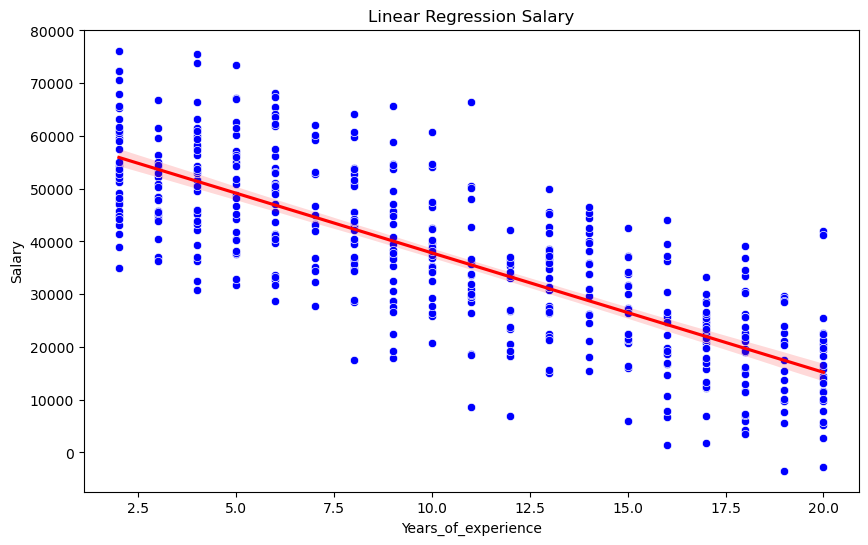

In [5]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Years_of_experience', y='Salary', data=df, color='blue')
sns.regplot(x='Years_of_experience', y='Salary', data=df, scatter=False, color='red')
# Draws a regression line through the data

plt.xlabel('Years_of_experience')
plt.ylabel('Salary')
plt.title('Linear Regression Salary')

plt.show()

In [18]:
X = df[['Years_of_experience']]
# X is the independent variable (feature)
# We use experience to predict salary


y = df['Salary']
# y is the dependent variable (target)
# This is the value we want to predict


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Splits the dataset into:
#
# 80% training data
# 20% testing data
#
# random_state=42 ensures the same split every time

lr = LinearRegression()

lr.fit(X_train, y_train)
# Trains the model using the training data
# The model learns the relationship between
# Years of Experience and Salary

lr.score(X_train,y_train) 
lr.score(X_train, y_train)
# Calculates R² score on the training data
# R² tells us how well the model explains the salary variation

0.624202770534565

In [8]:
lr.score(X_test,y_test) 
# Calculates R² score on unseen test data
# This helps evaluate how well the model generalizes

0.6140837390506503

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = lr.predict(X_test)

In [10]:
mean_absolute_error(y_test, y_pred)
# Calculates the average absolute difference
# between actual salary and predicted salary
#
# Lower MAE = better model

7905.114728709235

In [11]:
mean_squared_error(y_test, y_pred)
# Calculates the average squared difference
# between actual and predicted salary
#
# Lower MSE = better model

93933277.379471

In [12]:
r2_score(y_test, y_pred) # same as lr.score(X_test,y_test) 
# Calculates R² score on the test data
#
# R² closer to 1 = better fit
#
# This is approximately the same as:
# lr.score(X_test, y_test)

0.6140837390506503

In [13]:
lr.coef_

array([-2303.38707695])

In [14]:
lr.intercept_

np.float64(60961.340880280535)

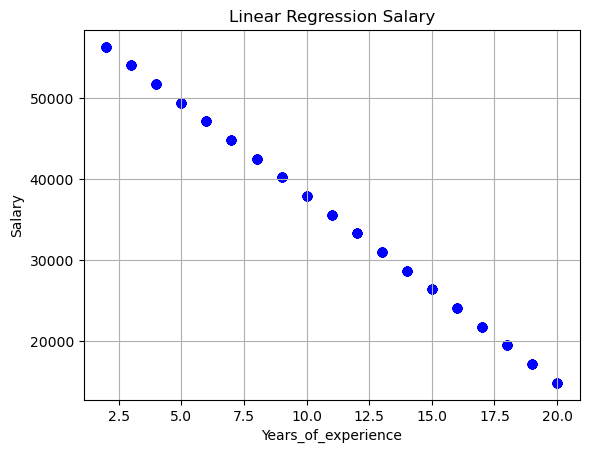

In [17]:
coefficients = lr.coef_
intercept = lr.intercept_
# Gets the slope/coefficient learned by the model
# Gets the intercept learned by the model

x = np.linspace(0, 20, 100)
y = coefficients*X + intercept

plt.scatter(X, y, label=f'y = {coefficients[0]}X + {intercept}', color='blue')
# Plots the regression predictions
# and displays the linear equation as the label

plt.xlabel('Years_of_experience')
plt.ylabel('Salary')
plt.title('Linear Regression Salary')

plt.grid()
plt.show()